## 1. Problem Definition
# Machine Learning System for Product Recommendation Prediction

## Dataset
Women's E-Commerce Clothing Reviews dataset from Kaggle:  
https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews  

This dataset contains customer reviews along with a label indicating whether the product was recommended.

---

## Problem

E-commerce platforms receive large number of customer reviews, finding it hard to manually analyse whether a product is recommended or not. Understanding customer opinion is important for improving product quality, customer satisfaction, and business decision making. 

---

## Objective

The objective of this project is to develop a machine learning system that can predict whether a product is recommeded based on the text of a customers review. 

## Task Type

- Input: Review text  
- Output: Recommended (1) / Not Recommended (0)  
- Type: Supervised Learning  
- Problem: Binary Classification  

---

Machine learning can learn patterns from past reviews and automatically make predictions on new ones. This helps save time and improves scalability.

## 2. Import Libraries

In [1]:
# ==============================
# IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud
from joblib import dump

## 3. Data Loading

In [2]:
# ==============================
# LOAD DATASET
# ==============================

df = pd.read_csv("Womens Clothing E-Commerce Reviews.csv")

# Rename columns for easier use
df = df.rename(columns={
    'Review Text': 'review',
    'Recommended IND': 'recommended'
})

df.head()

,Unnamed: 0,Clothing ID,Age,Title,review,Rating,recommended,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


## 4. Data Cleaning

In [3]:
# Before cleaning
print("Before cleaning:", df.shape)

# Drop missing reviews
df = df.dropna(subset=["review"])

# After cleaning
print("After cleaning:", df.shape)

Before cleaning: (23486, 11)
After cleaning: (22641, 11)


## 4. Exploratory Data Analysis (EDA)

In [4]:
# =======================
# Basic Info
# =======================

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 22641 entries, 0 to 23485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Unnamed: 0               22641 non-null  int64 
 1   Clothing ID              22641 non-null  int64 
 2   Age                      22641 non-null  int64 
 3   Title                    19675 non-null  object
 4   review                   22641 non-null  object
 5   Rating                   22641 non-null  int64 
 6   recommended              22641 non-null  int64 
 7   Positive Feedback Count  22641 non-null  int64 
 8   Division Name            22628 non-null  object
 9   Department Name          22628 non-null  object
 10  Class Name               22628 non-null  object
dtypes: int64(6), object(5)
memory usage: 2.1+ MB


Unnamed: 0                    0
Clothing ID                   0
Age                           0
Title                      2966
review                        0
Rating                        0
recommended                   0
Positive Feedback Count       0
Division Name                13
Department Name              13
Class Name                   13
dtype: int64

In [5]:
# =======================
# Class Distribution
# =======================
df['recommended'].value_counts()

recommended
1    18540
0     4101
Name: count, dtype: int64

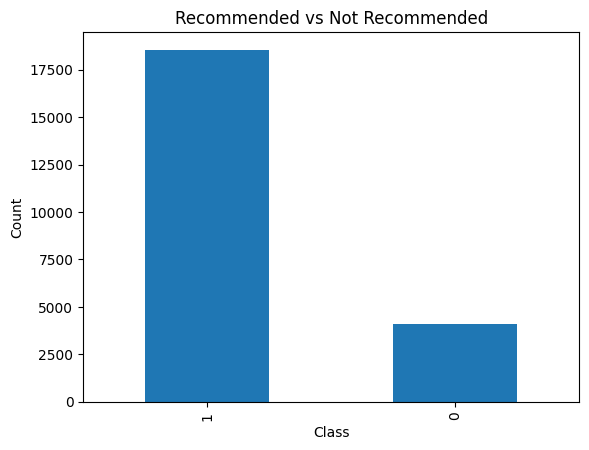

In [6]:
df['recommended'].value_counts().plot(kind='bar')
plt.title("Recommended vs Not Recommended")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

This shows the distribution of the target variable. There is a slight imbalance, 
so evaluation metrics like F1-score are important.

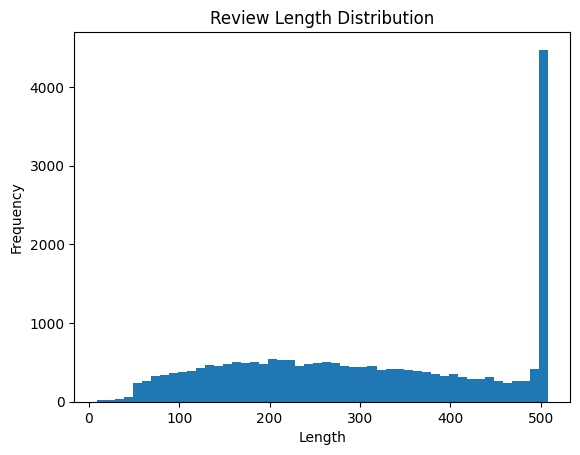

In [7]:
# =======================
# Review Length
# =======================

df['review_length'] = df['review'].apply(lambda x: len(str(x)))
plt.hist(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

This helps us understand how long the reviews are. Longer reviews may contain more useful information.

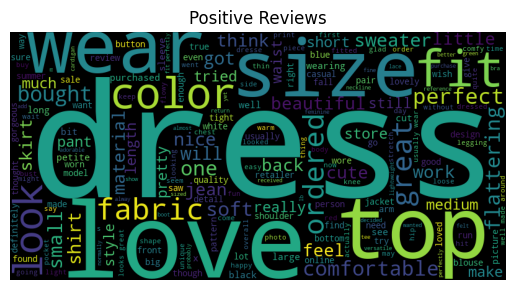

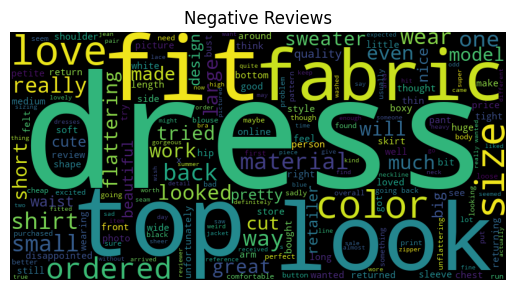

In [8]:
# =======================
# WordCloud
# =======================

positive_text = " ".join(df[df['recommended'] == 1]['review'].dropna())
negative_text = " ".join(df[df['recommended'] == 0]['review'].dropna())

wc = WordCloud(width=800, height=400)

plt.imshow(wc.generate(positive_text))
plt.axis("off")
plt.title("Positive Reviews")
plt.show()

plt.imshow(wc.generate(negative_text))
plt.axis("off")
plt.title("Negative Reviews")
plt.show()

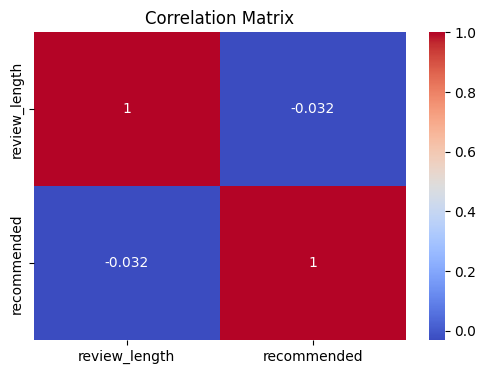

In [9]:
# =======================
# Correlation Matirx
# =======================

plt.figure(figsize=(6,4))

df['review_length'] = df['review'].apply(lambda x: len(str(x)))
numeric_cols = ["review_length", "recommended"]
corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

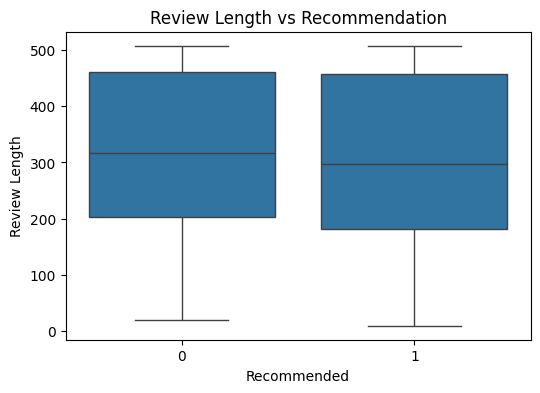

In [10]:
# =======================
# Review Length Vs Target
# =======================

plt.figure(figsize=(6,4))
sns.boxplot(x="recommended", y="review_length", data=df)
plt.title("Review Length vs Recommendation")
plt.xlabel("Recommended")
plt.ylabel("Review Length")

plt.show()

This boxplot shows the relationship between review length and recommendation.

It can be seen that recommended reviews are generally longer compared to not recommended ones. 
This suggests that customers who are satisfied tend to write more detailed feedback.

Therefore, review length can be considered a useful feature for prediction.

## 5. Data Preprocessing

In [11]:
# =======================
# TEXT CLEANING
# =======================

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def remove_stopwords(text):
    return " ".join([w for w in text.split() if w not in ENGLISH_STOP_WORDS])

def preprocess(text):
    text = clean_text(text)
    text = remove_stopwords(text)
    return text

df['clean_review'] = df['review'].apply(preprocess)

## 6. Feature Engineering 
TF-IDF(**Term Frequency- Inverse Document Frequency**) is used to convert text into numerical form. It gives more importance to meaningful words and reduces the impact of common words.

In [12]:
tfidf = TfidfVectorizer(max_features=5000)

X = df['clean_review']
y = df['recommended']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

## 7.Feature Extraction and Train-Test Split

The cleaned text data is converted into numerical form using TF-IDF (Term Frequency-Inverse Document Frequency).

To prevent data leakage:
- The dataset is first split into training and testing sets
- TF-IDF is fitted only on the training data
- The same transformation is applied to the test data

Two feature sizes (3000 and 5000) are tested to compare model performance.

In [13]:
# =======================
# FEATURES AND TARGET
# =======================

X = df['clean_review']
y = df['recommended']

# TRAIN-TEST SPLIT (to avoid data leakage)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

LogisticRegression(max_iter=1000)
MultinomialNB()
RandomForestClassifier(n_estimators=100)

# TF-IDF WITH DIFFERENT FEATURE SIZES

# 5000 features
tfidf_5000 = TfidfVectorizer(max_features=5000)
X_train_5000 = tfidf_5000.fit_transform(X_train)
X_test_5000 = tfidf_5000.transform(X_test)

# 3000 features
tfidf_3000 = TfidfVectorizer(max_features=3000)
X_train_3000 = tfidf_3000.fit_transform(X_train)
X_test_3000 = tfidf_3000.transform(X_test)

# CHECK SHAPES

print("5000 features:", X_train_5000.shape, X_test_5000.shape)
print("3000 features:", X_train_3000.shape, X_test_3000.shape)

5000 features: (18112, 5000) (4529, 5000)
3000 features: (18112, 3000) (4529, 3000)


## 8. Model Training

In [14]:
# Logistic Regression (Base)
lr_base = LogisticRegression(max_iter=1000)
lr_base.fit(X_train_5000, y_train)

# Logistic Regression (Tuned)
lr_tuned = LogisticRegression(C=10, max_iter=1000)
lr_tuned.fit(X_train_5000, y_train)

# Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_5000, y_train)

        # Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_5000, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## 9. Model Evaluation

In [15]:
def evaluate(y_true, y_pred, name):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred))


# Generate predictions first
lr_pred = lr_base.predict(X_test_5000)
nb_pred = nb.predict(X_test_5000)
rf_pred = rf.predict(X_test_5000)

# Now evaluate
evaluate(y_test, lr_pred, "Logistic Regression")
evaluate(y_test, nb_pred, "Naive Bayes")
evaluate(y_test, rf_pred, "Random Forest")


Logistic Regression
Accuracy: 0.8862883638772356
              precision    recall  f1-score   support

           0       0.79      0.51      0.62       820
           1       0.90      0.97      0.93      3709

    accuracy                           0.89      4529
   macro avg       0.84      0.74      0.78      4529
weighted avg       0.88      0.89      0.88      4529


Naive Bayes
Accuracy: 0.8480900861117244
              precision    recall  f1-score   support

           0       0.92      0.18      0.30       820
           1       0.85      1.00      0.91      3709

    accuracy                           0.85      4529
   macro avg       0.88      0.59      0.61      4529
weighted avg       0.86      0.85      0.80      4529


Random Forest
Accuracy: 0.8602340472510488
              precision    recall  f1-score   support

           0       0.82      0.29      0.43       820
           1       0.86      0.99      0.92      3709

    accuracy                           0.86   

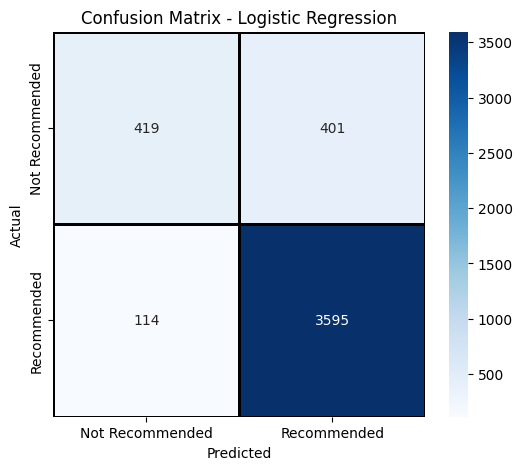

In [16]:
# =======================
# Confusion Matrix
# =======================

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            linewidths=2,
            linecolor='black',
            xticklabels=['Not Recommended', 'Recommended'],
            yticklabels=['Not Recommended', 'Recommended'])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 10. Cross Validation

In [17]:
# =======================
# CROSS VALIDATION
# =======================

from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():
    scores = cross_val_score(model, X_train_5000, y_train, cv=5, scoring='accuracy')
    
    print(f"{name}:")
    print("Scores:", scores)
    print("Mean Accuracy:", scores.mean())
    print("-" * 30)

Logistic Regression:
Scores: [0.88407397 0.87855368 0.88707896 0.88348978 0.88928769]
Mean Accuracy: 0.8844968179096279
------------------------------
Naive Bayes:
Scores: [0.84681203 0.84129175 0.84621756 0.84676974 0.84842628]
Mean Accuracy: 0.8459034730104144
------------------------------
Random Forest:
Scores: [0.86033674 0.85095225 0.86195472 0.85726118 0.86195472]
Mean Accuracy: 0.8584919221983972
------------------------------


## 11. Model Comparison

In [18]:
results = []

for name, model in models.items():
    model.fit(X_train_5000, y_train)
    preds = model.predict(X_test_5000)
    
    acc = accuracy_score(y_test, preds)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
0,Logistic Regression,0.886288
2,Random Forest,0.862000
1,Naive Bayes,0.848090


Cross-validation is used to evaluate model performance across multiple data splits, 
making the results more reliable.

Different models are compared based on their accuracy scores. 
This helps in selecting the best model for the final system.

Logistic Regression performed the best among all models, 
both in cross-validation and test evaluation. 
Therefore, it was selected as the final model.

## 12. Debugging and Improvements

During model evaluation, it was observed that some models achieved high accuracy but had lower recall for the "Not Recommended" class. This indicates that the models struggled to correctly identify negative reviews.

To improve performance, multiple models were tested and compared, including Logistic Regression, Naive Bayes, and Random Forest. Logistic Regression performed best overall.

TF-IDF feature size was also adjusted (3000 and 5000 features) to improve text representation.

Additionally, confusion matrices were analysed to understand misclassification patterns, and hyperparameter tuning was applied using GridSearchCV to further optimise the model.

## 13. Hyperparameter Tuning

In [19]:
params = {'C': [0.1, 1, 10]}

grid = GridSearchCV(LogisticRegression(max_iter=200), params, cv=5)
grid.fit(X_train_5000, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1}


## 14. Model Saving

In [20]:
from joblib import dump

dump(best_model, "model.pkl")
dump(tfidf, "vectorizer.pkl")

['vectorizer.pkl']

## 15. Conclusion

In this project, multiple machine learning models were trained to predict whether a product is recommended based on review text.

Logistic Regression performed the best overall in terms of accuracy and F1-score. 
Cross-validation confirmed that the model is stable and generalizes well.

TF-IDF with 5000 features provided better performance compared to 3000 features.

This model can be used in real-world applications to automatically analyse customer feedback.